## 필요 모듈 설치

In [5]:
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.2/526.2 kB 8.7 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
!pip install JPype1

In [1]:
!pip install pyahocorasick

In [7]:
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 13.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.9/444.9 kB 9.7 MB/s eta 0:00:0000:01

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 필요 라이브러리 호출

In [1]:
import pandas as pd
import numpy as np
import re #Regular Expression 특수문자, 반복 패턴 처리 용이
from collections import Counter
import os
import sys

#시각화
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import plotly.graph_objects as go  # Sankey Diagram

from konlpy.tag import Okt
'''
okt = Okt()
nouns = okt.nouns("맛있는 호박고구마 5kg 특가")
print(nouns) # 출력: ['호박고구마', '특가']
'''
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

# 작업 환경이 리눅스인지 윈도우인지 판별
import platform

if platform.system() == 'Linux':
    # 도커(리눅스) 환경 설정
    file_path = '/workspace/product_and_recipe_data_collection/refined_grocery_csv_for_classification/ML_grocery_data_sampled.csv'
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
else:
    # 윈도우 환경 설정
    file_path = r'C:\Users\LG\OneDrive\Desktop\REF_Classification_For_Ingredient_Recognition\product_and_recipe_data_collection\refined_grocery_csv_for_classification\ML_grocery_data_sampled.csv'
    font_path = 'C:/Windows/Fonts/malgun.ttf'

## 변수 설명

product_name: 1차 정제 제품명

category_large: 대분류 카테고리

category_medium: 중분류 카테고리

item_type: 제품의 카테고리 태그

grocery_item_name: 식재료 이름(타겟)

brand_name: 제품의 브랜드 명

## 데이터 전처리

In [2]:
grocery_df = pd.read_csv(file_path, encoding='utf-8')

print("Grocery data shape:", grocery_df.shape)

display(grocery_df.head(5))

grocery_df.info()

Grocery data shape: (1143, 6)


,product_name,category_large,category_medium,item_type,grocery_item_name,brand_name
0,[마이너피겨스] 유기농 오트음료,음료,주스,BEVERAGE,오트음료,마이너피겨스
1,[마이셰프] 찹스테이크,간편식,밀키트,RTC_MEAL,밀키트,마이셰프
2,[건강한우리집비옴] 생 아몬드 분말,조미료,가루분말,SAUCE_SEASONING,아몬드 분말,건강한우리집비옴
3,[김구원선생] 매일 마시는 국산 콩물,채소/곡물류,콩/두부,SIMPLE_PROCESSED,콩물,김구원선생
4,스코티시 리더 슈프림,술,기타 주류,ALCOHOL,위스키,스코티시


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   product_name       1143 non-null   object
 1   category_large     1143 non-null   object
 2   category_medium    1143 non-null   object
 3   item_type          1143 non-null   object
 4   grocery_item_name  1143 non-null   object
 5   brand_name         1143 non-null   object
dtypes: object(6)
memory usage: 53.7+ KB


### 제품명 정제 및 컬럼 생성 메서드

In [4]:
from datetime import datetime
import json
# 파서 import
from product_name_parser import REFProductNameParser, create_brand_matcher

class REF_Grocery_Data_Cleaner_prototype:
        self.new_brands_added = set()
        self.update_parser()

    def update_parser(self):
        # 브랜드 매처 생성 로직을 사용 -> 브랜드 검색 사전 만들기
        self.matcher = create_brand_matcher(self.brand_dictionary)
        # 파서 클래스를 인스턴스
        self.parser = REFProductNameParser(brand_matcher=self.matcher)

    def refine_product_name(self, product_name: str):
        if not product_name or pd.isna(product_name):
            return product_name
        
        # 파서로 분석 수행 (브랜드 추출, 노이즈 제거 등)
        result = self.parser.parse(product_name)
        
        # 새로운 브랜드 발견 업데이트
        found_brand = result.brand_name
        if found_brand and found_brand not in self.brand_dictionary:
            self.brand_dictionary.add(found_brand)
            self.new_brands_added.add(found_brand)
            # 다음 행 처리에 즉시 반영
            self.update_parser()

        return result.refined_text

    def add_refined_column(self, df, input_col='product_name'):
        # cleaned_product_name 이라는 컬럼 생성
        print(f"[{input_col}] 컬럼 정제 및 브랜드 수집 중...")
        df['refined_product_name'] = df[input_col].apply(self.refine_product_name)
        return df

    def save_updated_dictionary(self, target_path):
        # 기존 브랜드 사전과 비교해 새로운 브랜드가 있을시 기존 브랜드 사전에 추가 및 데이터 저장
        if not self.new_brands_added:
            print("-" * 50)
            print("새로운 브랜드가 발견되지 않아 저장을 건너뜁니다.")
            print("-" * 50)
            return

        # 날짜 포맷팅
        date_str = datetime.now().strftime("%y_%m_%d")
        file_name = f"{date_str}_predict_grocery_dictionary.json"
        full_path = os.path.join(target_path, file_name)
        
        if not os.path.exists(target_path):
            os.makedirs(target_path)

        # 브랜드 사전을 정렬된 리스트(배열)로 변환하여 JSON 저장
        brand_list = sorted(list(self.brand_dictionary))
        with open(full_path, 'w', encoding='utf-8') as f:
            json.dump(brand_list, f, ensure_ascii=False, indent=4)
        
        print("-" * 50)
        print(f"신규 브랜드 {len(self.new_brands_added)}개 추가 발견.")
        print(f"JSON 사전 저장 완료: {full_path}")
        print("-" * 50)

# brand_name 컬럼의 유효한 값들을 중복 없애서 사전으로 만들기.
brand_dictionary = set(grocery_df['brand_name'].dropna().unique())

# 클리너 인스턴스 생성
cleaner = REF_Grocery_Data_Cleaner_prototype(brand_dictionary)

# 데이터 정제 및 새로운 컬럼 추가
# grocery_df에 직접 적용.
grocery_df = cleaner.add_refined_column(grocery_df, input_col='product_name')

# 결과 확인 (상위 5개 행)
print(grocery_df[['product_name', 'refined_product_name']].head())

# 지정된 경로에 JSON 사전 저장
TARGET_DIR = r"C:\Users\LG\OneDrive\Desktop\REF_Classification_For_Ingredient_Recognition\ML_dataset_smapled\grocery_classification_dataset\predict_brand_name" 
cleaner.save_updated_dictionary(TARGET_DIR)

IndentationError: unindent does not match any outer indentation level (<string>, line 10)

술 제품들의 제품명이 잘림 -> 브랜드를 없애고 정제 제품명으로 바꾼 것이 문제.

In [3]:
from datetime import datetime
import json
# 파서 import
from product_name_parser import REFProductNameParser, create_brand_matcher

class REF_Grocery_Data_Cleaner:
    def __init__(self, brand_set: set):
        self.brand_dictionary = brand_set
        self.new_brands_added = set()
        self.update_parser()

    def update_parser(self):
        # 브랜드 매처 및 파서 초기화
        self.matcher = create_brand_matcher(self.brand_dictionary)
        self.parser = REFProductNameParser(brand_matcher=self.matcher)

    def refine_product_name(self, row, input_col='product_name', category_col='category_large'):
        product_name = row[input_col]
        category = str(row[category_col]).strip() if category_col in row else ""

        if not product_name or pd.isna(product_name):
            return product_name
        
        # 파서 실행 (브랜드 추출 및 괄호/특수문자 등 노이즈 제거)
        result = self.parser.parse(product_name)
        
        # 브랜드 사전 업데이트 (신규 브랜드 발견 시)
        # To-Do '단락 지우기'
        found_brand = result.brand_name
        if found_brand and found_brand not in self.brand_dictionary:
            self.brand_dictionary.add(found_brand)
            self.new_brands_added.add(found_brand)
            self.update_parser()

        # 술 카테고리 여부에 따른 분기 처리
        if category == '술':
            # 브랜드가 식별되었다면, 정제된 텍스트 앞에 브랜드를 다시 붙여줌
            # 파서가 정제 과정에서 브랜드를 삭제하더라도 여기서 복구됨
            refined = result.refined_text
            if found_brand and found_brand not in refined:
                return f"{found_brand} {refined}".strip()
            return refined
        else:
            # 술이 아닌 경우 기존 로직대로 정제된 텍스트(일반적으로 브랜드 제외) 반환
            return result.refined_text

    def add_refined_column(self, df, input_col='product_name', category_col='category_large'):
        print(f"[{input_col}] 정제 작업 시작 (대상: {len(df)}행)...")
        
        # 행(row) 전체를 전달하여 카테고리 값을 참조
        df['refined_product_name'] = df.apply(
            lambda row: self.refine_product_name(row, input_col, category_col), 
            axis=1
        )
        return df

    def save_updated_dictionary(self, target_path):
        if not self.new_brands_added:
            print("-" * 50)
            print("새로운 브랜드가 발견되지 않아 저장을 건너뜁니다.")
            print("-" * 50)
            return

        date_str = datetime.now().strftime("%y_%m_%d")
        file_name = f"{date_str}_predict_grocery_dictionary.json"
        full_path = os.path.join(target_path, file_name)
        
        if not os.path.exists(target_path):
            os.makedirs(target_path)

        brand_list = sorted(list(self.brand_dictionary))
        with open(full_path, 'w', encoding='utf-8') as f:
            json.dump(brand_list, f, ensure_ascii=False, indent=4)
        
        print("-" * 50)
        print(f"작업 완료: 신규 브랜드 {len(self.new_brands_added)}개 추가됨.")
        print(f"저장 경로: {full_path}")
        print("-" * 50)

In [4]:
brand_dictionary = set(grocery_df['brand_name'].dropna().unique())
ref_cleaner = REF_Grocery_Data_Cleaner(brand_dictionary)

# 데이터 정제
grocery_df = ref_cleaner.add_refined_column(grocery_df, input_col='product_name', category_col='category_large')

# 결과 확인
print(grocery_df[['category_large', 'product_name', 'refined_product_name']].head())

# JSON 사전 저장
TARGET_DIR = r"C:\Users\LG\OneDrive\Desktop\REF_Classification_For_Ingredient_Recognition\ML_dataset_smapled\grocery_classification_dataset\predict_brand_name"
ref_cleaner.save_updated_dictionary(TARGET_DIR)

display(grocery_df.info())

[product_name] 정제 작업 시작 (대상: 1143행)...
  category_large          product_name refined_product_name
0             음료     [마이너피겨스] 유기농 오트음료             유기농 오트음료
1            간편식          [마이셰프] 찹스테이크                찹스테이크
2            조미료   [건강한우리집비옴] 생 아몬드 분말             생 아몬드 분말
3         채소/곡물류  [김구원선생] 매일 마시는 국산 콩물         매일 마시는 국산 콩물
4              술           스코티시 리더 슈프림          스코티시 리더 슈프림
--------------------------------------------------
새로운 브랜드가 발견되지 않아 저장을 건너뜁니다.
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   product_name          1143 non-null   object
 1   category_large        1143 non-null   object
 2   category_medium       1143 non-null   object
 3   item_type             1143 non-null   object
 4   grocery_item_name     1143 non-null   object
 5   brand_name

None

In [5]:
condition = (grocery_df['refined_product_name'].str.len() <= 1) | (grocery_df['refined_product_name'].str.len() >= 200)
invalid_data = grocery_df[condition]

count = len(invalid_data)

if count > 0:
    print(f"(1자 이하 또는 200자 이상)에 해당하는 데이터가 {count}건 발견되었습니다.")
    print("-" * 50)
    # 발견된 데이터의 실제 내용 출력
    print(invalid_data['refined_product_name'])
    print("-" * 50)
else:
    print("모든 데이터가 정상 범위(2자 ~ 199자) 내에 있습니다.")

(1자 이하 또는 200자 이상)에 해당하는 데이터가 2건 발견되었습니다.
--------------------------------------------------
976     무
1004    꿀
Name: refined_product_name, dtype: object
--------------------------------------------------


## 데이터 시각화

### WordCloud 사용으로 product_name, refined_product_name 의 구성 단어 빈도 시각화

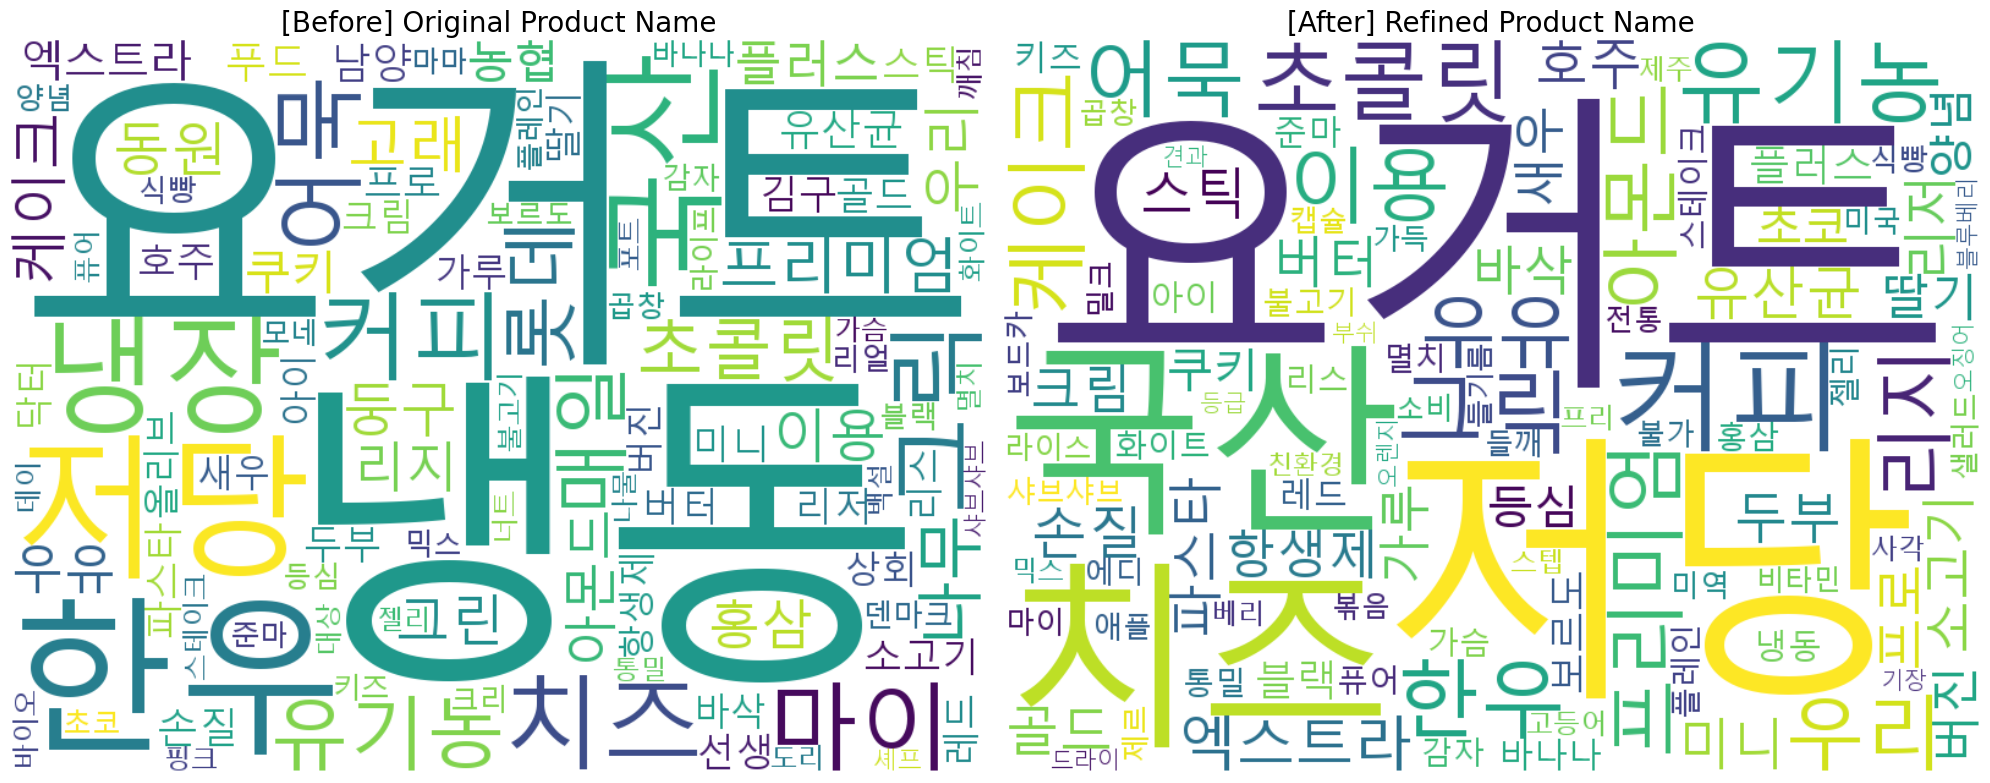


[비교 결과 상위 50개 단어]
원본(product_name)     | 정제후(refined_product_name)
-------------------------------------------------------
냉동(31)               | 요거트(30)
요거트(30)              | 저당(24)
한우(26)               | 국산(23)
저당(24)               | 치즈(22)
냉장(24)               | 커피(20)
국산(23)               | 유기농(18)
치즈(23)               | 그릭(18)
그릭(22)               | 초콜릿(17)
마이(20)               | 한우(16)
커피(20)               | 이용(15)
어묵(19)               | 케이크(15)
유기농(18)              | 어묵(15)
매일(17)               | 프리미엄(14)
롯데(17)               | 우리(14)
초콜릿(17)              | 아몬드(13)
나무(16)               | 리지(13)
프리미엄(16)             | 우유(13)
고래(16)               | 엑스트라(12)
둥구(15)               | 손질(11)
이용(15)               | 유산균(11)
동원(15)               | 호주(10)
우리(15)               | 골드(10)
케이크(15)              | 두부(10)
그린(14)               | 버터(10)
아몬드(13)              | 미니(10)
리지(13)               | 소고기(10)
우유(13)               | 스틱(10)
홍삼(13)               | 리저(10)
플러스(13)              | 파스

In [5]:
# 형태소 분석기 및 불용어 설정
okt = Okt()

# 식재료와 상관없는 빈출 불용어 리스트
stop_words = ['기획', '특가', '증정', '박스', '세트', '국내산', '내외', '중량', '입', '행사', '무료', '배송', '[26년 설]']

# 문장에서 명사만 추출하고 불용어를 제거하는 함수
def get_nouns_fast(text):
    if pd.isna(text): return ""
    # 명사 추출
    nouns = okt.nouns(str(text))
    # 한 글자 단어 제거 및 불용어 제거
    return [n for n in nouns if len(n) > 1 and n not in stop_words]

# 원본 제품명에서 명사 추출
grocery_df['nouns_original'] = grocery_df['product_name'].apply(get_nouns_fast)

# 정제된 제품명에서 명사 추출
grocery_df['nouns_refined'] = grocery_df['refined_product_name'].apply(get_nouns_fast)

# 리스트를 풀어서 전체 빈도 계산
all_nouns_product_name = [word for nouns in grocery_df['nouns_original'] for word in nouns]
all_nouns_refined_product_name = [word for nouns in grocery_df['nouns_refined'] for word in nouns]

counts_product_name = Counter(all_nouns_product_name)
counts_refined_product_name = Counter(all_nouns_refined_product_name)

# 워드 클라우드 생성 함수
def draw_wordcloud(word_counts, title, ax):
    wc = WordCloud(
        font_path=font_path,
        background_color='white',
        width=800,
        height=600,
        max_words=100
    ).generate_from_frequencies(word_counts)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=20)
    ax.axis('off')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# 왼쪽: 원본 데이터 워드클라우드
draw_wordcloud(counts_product_name, "[Before] Original Product Name", axes[0])

# 오른쪽: 정제 후(refined) 워드클라우드 [명칭 변경]
draw_wordcloud(counts_refined_product_name, "[After] Refined Product Name", axes[1])

plt.tight_layout()
plt.show()

# 상위 단어 수치 비교 출력
print("\n[비교 결과 상위 50개 단어]")
print(f"{'원본(product_name)':<20} | {'정제후(refined_product_name)':<20}")
print("-" * 55)
for (w1, c1), (w2, c2) in zip(counts_product_name.most_common(50), counts_refined_product_name.most_common(50)):
    print(f"{w1}({c1}):<20".split(':')[0].ljust(20) + " | " + f"{w2}({c2})")

1. 브랜드를 제거하지 않은 제품명 데이터에선 메일, 롯데, 남양 같은 브랜드들이 상위권을 차지함. 브랜드를 제거한 제품명에선 식재료 명이 더욱 많아졌음
   koNLPy 를 사용해 형용사나 부사같은 불필요한 수식어를 제거함으로서 추후 있을 모델학습의 효율을 늘릴 수 있을 것이라고 생각함.
   
2. 리지, 리저, 준마 등 (오/리지/날, 리저/브, 준마/이 다이긴죠 추정) 이런 식으로 과절단 되는 현상이 있는 것으로 보임. 이런 현상이 있을 시에 모델 학습에 많은 악영향을
   칠 것으로 보이기도 함.
   -> 불용어 처리(브랜드도 껴있는 것 같아서 별로 좋지 못할듯), 주류 특화 사전을 만들어 오리지날, 리저브, 준마이 다이긴죠 등으로 분석하도록 koNLPy 파인 튜닝

3. 요거트, 치즈, 커피, 한우 등 데이터가 몰려있는 경우가 많음. -> 데이터 어그멘테이션이 필수조건으로 보임. 


### WordCloud 사용해 grocery_item_name 의 중복도 시각화

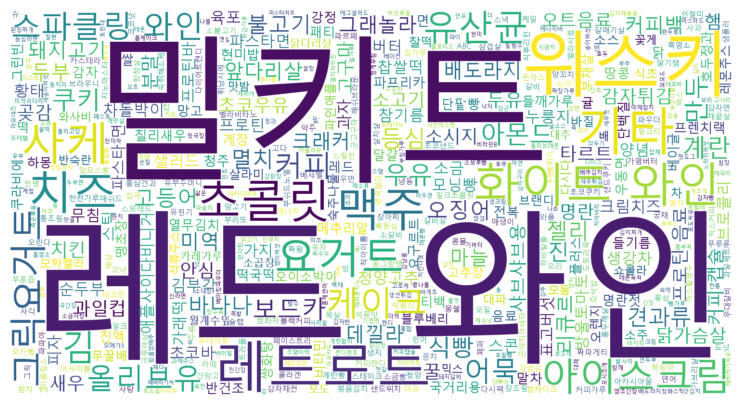

--------------------------------------------------------------------------------------------------------------
레드 와인(50)          | 밀키트(46)            | 위스키(42)            | 레트로트(24)           | 기타(19)            
화이트 와인(17)         | 사케(16)             | 맥주(16)             | 아이스크림(15)          | 초콜릿(15)           
요거트(14)            | 그릭요거트(14)          | 김(13)              | 유산균(13)            | 스파클링 와인(12)       
케이크(12)            | 올리브유(11)           | 쿠키(8)              | 보드카(8)             | 치즈(8)             
어묵(7)              | 계란(7)              | 등심(7)              | 진(6)               | 멸치(6)             
바나나(6)             | 우유(6)              | 식빵(6)              | 고등어(6)             | 만두(5)             
커피(5)              | 리큐르(5)             | 앞다리살(5)            | 데낄라(5)             | 견과류(5)            
크래커(5)             | 그래놀라(5)            | 커피백(5)             | 불고기(5)             | 오트음료(4)           
프로틴 음료(4)          | 명란(4)              | 과일컵(4)             | 감자

In [8]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

grocery_combined_text = " ".join(grocery_df['grocery_item_name']) # 워드 클라우드는 하나의 긴 텍스트를 받으니 조인으로 묶기

wordcloud = WordCloud(
    font_path=font_path,
    width=1500, 
    height=800,
    background_color='white',
    colormap='viridis',    # 색상 테마 설정
    max_words=1143        # 최대 표시 단어 수
).generate(grocery_combined_text)

# 시각화
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # 축 숨기기
plt.show()

grocery_item_name_counts = grocery_df['grocery_item_name'].value_counts().head(1143)

print("-" * 110)
items = [f"{item}({count})" for item, count in grocery_item_name_counts.items()]

num_cols = 5  # 한 줄에 5개씩 출력
for i in range(0, len(items), num_cols):
    row = items[i : i + num_cols]
    # 각 항목을 20자 너비로 왼쪽 정렬하여 열을 맞춤
    print(" | ".join(f"{item:<18}" for item in row))
print("-" * 110)

1. 식재료 전부를 찍어봤을 때 밀키트, 레드 와인, 화이트 와인, 레트로트, 위스키 등 주류 또는 간편식에 데이터가 치중되어있음.
   -> 어그멘테이션이 필수임, 주류는 제품 이름 안에 브랜드가 포함된 경우가 대부분임. 이를 통해 주류 필터 사전을 통해 주류는 ML을 거치지않고 필터링 사전을 통해
      분류하는 것도 좋은 선택일 듯함.
   
3. 사람들이 많이 소비하는 채소류나, 식품의 데이터가 적음. 추후에 따로 채워야할 것.

In [14]:
def plot_class_frequency(df, column_name, top_n=None):
    # 데이터 집계 및 정렬
    counts = grocery_df['category_large'].value_counts()
    
    if top_n:
        counts = counts.head(top_n)
        title = f'{column_name} 빈도수 (상위 {top_n}개)'
    else:
        title = f'{column_name} 클래스별 빈도수 확인'

    # 시각화 설정
    plt.figure(figsize=(15, 7))
    sns.barplot(x=counts.index, y=counts.values, palette='coolwarm')

    # 수치 표시 (막대 위에 숫자 적기)
    for i, v in enumerate(counts.values):
        plt.text(i, v + (max(counts.values) * 0.01), str(v), 
                 ha='center', fontsize=10, fontweight='bold')

    # 라벨 및 타이틀 최적화
    plt.title(f'<b>{title}</b>', fontsize=16, pad=20)
    plt.xlabel('클래스명', fontsize=12)
    plt.ylabel('데이터 개수', fontsize=12)
    plt.xticks(rotation=45, ha='right') # 라벨 겹침 방지
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    
    plt.show()

# 실행 예시 1: 대분류 빈도 확인
plot_class_frequency(grocery_df, 'category_large')

# 실행 예시 2: 아이템 타입 빈도 확인 (데이터가 많을 경우 상위 30개만)
# plot_class_frequency(grocery_df, 'item_type', top_n=30)

NameError: name 'category_large' is not defined

### Sankey Diagram 시각화

In [13]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# 1. 데이터 흐름 정의 (수직적 위계만 추출)
# 단계 1: 대분류 -> 중분류
l_flow1 = grocery_df.groupby(['category_large', 'category_medium']).size().reset_index(name='v')
# 단계 2: 중분류 -> 아이템 타입
l_flow2 = grocery_df.groupby(['category_medium', 'item_type']).size().reset_index(name='v')

# 2. 노드 이름 고유화 및 인덱싱 (중복 방지를 위해 공백 개수를 다르게 설정)
# 대분류: 이름 + " " (공백 1개)
# 중분류: 이름 + "  " (공백 2개)
# 아이템: 이름 (공백 없음)
unique_l_large = [n + " " for n in sorted(grocery_df['category_large'].unique())]
unique_l_medium = [n + "  " for n in sorted(grocery_df['category_medium'].unique())]
unique_center = sorted(grocery_df['item_type'].unique())

all_nodes = unique_l_large + unique_l_medium + unique_center
node_map = {n: i for i, n in enumerate(all_nodes)}

# 3. 링크 데이터 생성 (이름 겹침 방지 맵핑)
links = []

# 대분류(공백1) -> 중분류(공백2)
for _, r in l_flow1.iterrows():
    links.append({
        's': node_map[r['category_large'] + " "], 
        't': node_map[r['category_medium'] + "  "], 
        'v': r['v']
    })

# 중분류(공백2) -> 아이템 타입(공백0)
for _, r in l_flow2.iterrows():
    links.append({
        's': node_map[r['category_medium'] + "  "], 
        't': node_map[r['item_type']], 
        'v': r['v']
    })

links_df = pd.DataFrame(links)

# 4. 색상 설정 (기존 로직 유지)
colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3', '#FF6692', '#B6E880']
large_cat_list = sorted(grocery_df['category_large'].unique())
color_map = {cat: colors[i % len(colors)] for i, cat in enumerate(large_cat_list)}

node_colors = []
for n in all_nodes:
    clean_n = n.strip()
    if clean_n in color_map:
        node_colors.append(color_map[clean_n])
    else:
        node_colors.append("#E5ECF6")

link_colors = []
for _, row in links_df.iterrows():
    src_node = all_nodes[row['s']].strip()
    base_color = color_map.get(src_node, "#ABB2B9")
    r, g, b = tuple(int(base_color.lstrip('#')[i:i+2], 16) for i in (0, 2, 4))
    link_colors.append(f"rgba({r}, {g}, {b}, 0.3)")

# 5. 좌표 설정 (직사각형 형태 유지)
x_pos = [0.0]*len(unique_l_large) + [0.5]*len(unique_l_medium) + [1.0]*len(unique_center)

def get_y(n_list):
    if len(n_list) <= 1: return [0.5]
    return [i / (len(n_list) - 1) for i in range(len(n_list))]

y_pos = get_y(unique_l_large) + get_y(unique_l_medium) + get_y(unique_center)

# 6. 시각화
fig = go.Figure(data=[go.Sankey(
    arrangement = "fixed", # 직사각형 고정
    node = dict(
        pad = 20,
        thickness = 30,
        label = [n.strip() for n in all_nodes],
        x = x_pos,
        y = y_pos,
        color = node_colors,
        line = dict(color = "black", width = 0.5)
    ),
    link = dict(
        source = links_df['s'],
        target = links_df['t'],
        value = links_df['v'],
        color = link_colors
    )
)])

fig.update_layout(
    title_text="<b>[식재료 데이터 흐름]</b> 계층 ",
    font=dict(size=12, color="black"),
    width=1600,
    height=1000,
    margin=dict(l=50, r=50, t=100, b=50),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.show()

1. 대분류 데이터에 불균형 존재함. 간식류(191), 술(186), 기타(162) 카테고리가 전체 흐름의 큰 비중을 차지. 반면, 상온식품(27)이나 과일/견과류(47)는 상대적으로 비중이     너무 적음.

2. 중분류에서도 디저트/케이크(66), 밀키트(47) 등 특정 품목에 데이터가 쏠려 있어, 모델이 빈도가 낮은 품목을 학습할 때 어려움을 겪을 수 있다고 생각.

3. 기타에 대한 취급. 기타를 어떻게 취급할까 생각해봤는데 이 데이터셋에서 결측치로 취급해도 되지않을까 싶음. 모델이 이 노이즈를 학습한다면 득이되는 것은 없을 듯.

4. 간편식에서 빵류가 보임. 이는 데이터 프레임 제작과정중 실수가 있었음을 시사함.
